# 22 - k vecinos m?s cercanos (k-NN) en R: flujo completo

## Prop?sito de la sesi?n

En esta sesi?n vas a:

1. Entender qu? problema resuelve k-NN.
2. Repasar distancia y su generalizaci?n (Minkowski).
3. Ver por qu? normalizar es cr?tico.
4. Implementar un flujo train/test reproducible.
5. Comparar accuracy para distintos valores de `k`.
6. Interpretar matriz de confusi?n.
7. Practicar con ejercicios que inviten a razonar.


## k-NN dentro de ciencia de datos

k-NN es un modelo supervisado de clasificaci?n basado en similitud.
No aprende una f?rmula cerrada: para predecir, consulta los vecinos m?s cercanos del entrenamiento.


In [1]:
# Muestra de contexto: dataset y clases.
# Usaremos iris por ser multiclase y f?cil de visualizar.
data(iris)

# Resumen de tama?o y clases.
cat('Filas:', nrow(iris), 'Columnas:', ncol(iris), '
')
table(iris$Species)


Filas: 150 Columnas: 5 



    setosa versicolor  virginica 
        50         50         50 

## Distancia euclidiana y generalizaci?n Minkowski

Dos distancias clave:

- Euclidiana (`p = 2`): ra?z de suma de cuadrados.
- Manhattan (`p = 1`): suma de diferencias absolutas.

Minkowski unifica ambas con el par?metro `p`.


In [2]:
# Calcula distancia Minkowski entre dos vectores.
minkowski <- function(x, z, p = 2) {
  # |x-z|^p, suma y raiz p-esima.
  sum(abs(x - z)^p)^(1 / p)
}

# Ejemplo numerico.
x <- c(1, 4, 2)
z <- c(3, 1, 2)

cat('Manhattan (p=1):', minkowski(x, z, p = 1), '
')
cat('Euclidiana (p=2):', minkowski(x, z, p = 2), '
')


Manhattan (p=1): 5 


Euclidiana (p=2): 3.605551 


## Por qu? normalizar importa

Si una variable est? en escala grande, domina la distancia.
En k-NN eso cambia qui?n es ?vecino cercano? y puede degradar el modelo.


In [3]:
# Ejemplo simple: dos variables en escalas muy distintas.
a <- c(0.20, 1000)
b <- c(0.25, 1020)

# Distancia sin normalizar.
d_sin <- sqrt(sum((a - b)^2))

# Normaliza manualmente con media/sd de un mini conjunto.
M <- rbind(a, b, c(0.10, 980), c(0.30, 1040))
mu <- colMeans(M)
sd_ <- apply(M, 2, sd)

scale_with <- function(M, mu, sd_) {
  # Estandariza columna a columna.
  sweep(sweep(as.matrix(M), 2, mu, '-'), 2, sd_, '/')
}

M_sc <- scale_with(M, mu, sd_)
d_con <- sqrt(sum((M_sc[1, ] - M_sc[2, ])^2))

cat('Distancia sin normalizar:', round(d_sin, 4), '
')
cat('Distancia normalizada:', round(d_con, 4), '
')


Distancia sin normalizar: 20.0001 


Distancia normalizada: 0.971 


## Cargar librer?a y preparar datos

Usaremos `class::knn`, que forma parte de paquetes recomendados en R.


In [4]:
# Carga k-NN; instala solo si hiciera falta.
if (!requireNamespace('class', quietly = TRUE)) {
  install.packages('class', repos = 'https://cloud.r-project.org')
}
library(class)

# Variables predictoras y clase objetivo.
X <- iris[, 1:4]
y <- iris$Species

# Inspeccion minima.
str(X)
table(y)


'data.frame':	150 obs. of  4 variables:
 $ Sepal.Length: num  5.1 4.9 4.7 4.6 5 5.4 4.6 5 4.4 4.9 ...
 $ Sepal.Width : num  3.5 3 3.2 3.1 3.6 3.9 3.4 3.4 2.9 3.1 ...
 $ Petal.Length: num  1.4 1.4 1.3 1.5 1.4 1.7 1.4 1.5 1.4 1.5 ...
 $ Petal.Width : num  0.2 0.2 0.2 0.2 0.2 0.4 0.3 0.2 0.2 0.1 ...


y
    setosa versicolor  virginica 
        50         50         50 

## Train/Test split reproducible

Separar entrenamiento y prueba evita evaluar sobre los mismos datos usados para ajustar.


In [5]:
# Semilla para reproducibilidad del split.
set.seed(2026)
idx <- sample(seq_len(nrow(X)), size = floor(0.75 * nrow(X)))

# Particiones train/test.
X_train <- X[idx, ]
X_test <- X[-idx, ]
y_train <- y[idx]
y_test <- y[-idx]

cat('Train:', nrow(X_train), 'Test:', nrow(X_test), '
')


Train: 112 Test: 38 


## Escalado correcto (sin data leakage)

Regla cr?tica:

1. Ajustar escala (media/sd) SOLO con train.
2. Aplicar esa misma transformaci?n a test.


In [6]:
# Parametros de escalado del train.
mu <- colMeans(X_train)
sd_ <- apply(X_train, 2, sd)

# Funcion de escalado reutilizable.
scale_with <- function(M, mu, sd_) {
  sweep(sweep(as.matrix(M), 2, mu, '-'), 2, sd_, '/')
}

# Transformacion coherente.
X_train_sc <- scale_with(X_train, mu, sd_)
X_test_sc <- scale_with(X_test, mu, sd_)


## Definir m?trica de accuracy

Accuracy = proporci?n total de predicciones correctas.


In [7]:
# Funcion de accuracy para clasificacion.
accuracy <- function(pred, real) {
  mean(pred == real)
}

# Ejemplo minimo de uso.
accuracy(c('a', 'b', 'b'), c('a', 'a', 'b'))


[1] 0.6666667

## Evaluar un modelo k-NN para un k fijo

Empezamos con `k = 11` para tener una referencia base.


In [8]:
# Entrena/predice k-NN con datos escalados.
k_base <- 11
pred_base <- knn(train = X_train_sc, test = X_test_sc, cl = y_train, k = k_base)

# Accuracy y matriz de confusion.
acc_base <- accuracy(pred_base, y_test)
cm_base <- table(real = y_test, pred = pred_base)

cat('Accuracy base:', round(acc_base, 4), '
')
cm_base


Accuracy base: 0.8947 


            pred
real         setosa versicolor virginica
  setosa         15          0         0
  versicolor      0         13         4
  virginica       0          0         6

## Barrido de k: sin escalar vs con escalar

Compararemos accuracy en test para varios `k` impares.


In [9]:
# Rango de k impares para reducir empates.
k_values <- seq(1, 31, by = 2)

# Vectores para guardar resultados.
acc_no_scale <- numeric(length(k_values))
acc_scale <- numeric(length(k_values))

# Recorre k y evalua ambos escenarios.
for (i in seq_along(k_values)) {
  k <- k_values[i]

  # Modelo sin escalar.
  pred_no <- knn(train = X_train, test = X_test, cl = y_train, k = k)
  acc_no_scale[i] <- accuracy(pred_no, y_test)

  # Modelo escalado correctamente.
  pred_sc <- knn(train = X_train_sc, test = X_test_sc, cl = y_train, k = k)
  acc_scale[i] <- accuracy(pred_sc, y_test)
}

# Tabla resumen.
resultados_k <- data.frame(
  k = k_values,
  acc_no_scale = round(acc_no_scale, 4),
  acc_scale = round(acc_scale, 4)
)
resultados_k


k,acc_no_scale,acc_scale
<dbl>,<dbl>,<dbl>
1,0.9737,0.8947
3,0.9737,0.9474
5,0.9474,0.9211
7,0.9474,0.9211
9,0.9474,0.9211
11,0.9474,0.8947
13,0.9474,0.9211
15,0.9474,0.9474
17,0.9474,0.8947


## Gr?fica de desempe?o por k

La gr?fica ayuda a elegir un `k` razonable y ver impacto de normalizaci?n.


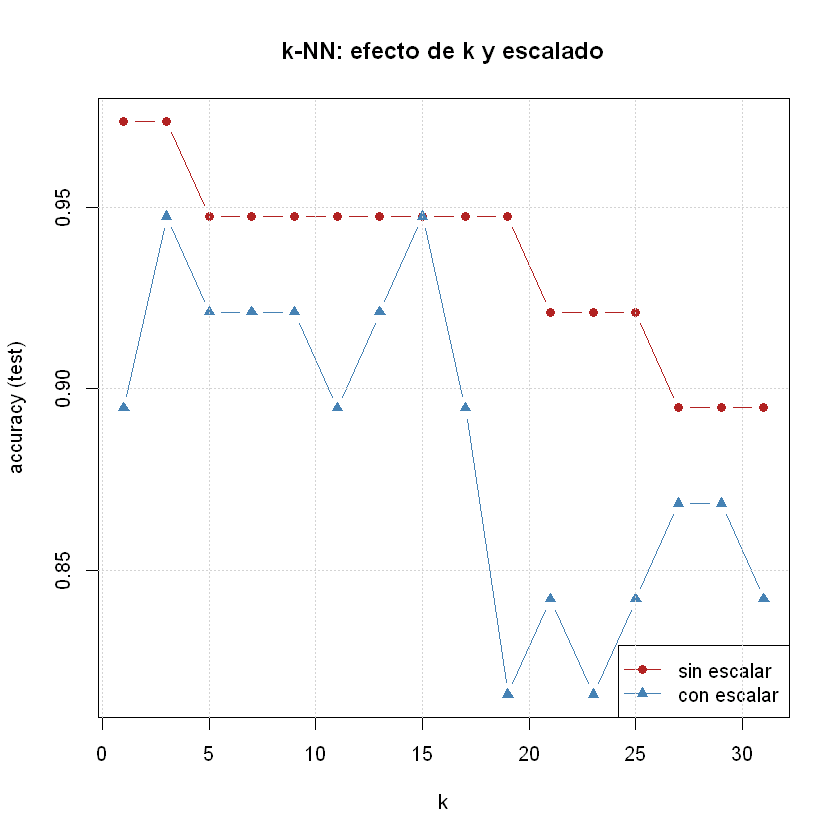

In [10]:
# Curvas de accuracy por k.
plot(
  k_values,
  acc_no_scale,
  type = 'b',
  pch = 16,
  col = 'firebrick',
  ylim = range(c(acc_no_scale, acc_scale)),
  xlab = 'k',
  ylab = 'accuracy (test)',
  main = 'k-NN: efecto de k y escalado'
)
lines(k_values, acc_scale, type = 'b', pch = 17, col = 'steelblue')
legend(
  'bottomright',
  legend = c('sin escalar', 'con escalar'),
  col = c('firebrick', 'steelblue'),
  pch = c(16, 17),
  lty = 1
)
grid()


## Elegir mejor k y analizar matriz de confusi?n

Seleccionamos el `k` con mayor accuracy en versi?n escalada.


In [11]:
# Mejor k en escenario escalado.
best_i <- which.max(acc_scale)
best_k <- k_values[best_i]

# Prediccion final con mejor k.
pred_best <- knn(train = X_train_sc, test = X_test_sc, cl = y_train, k = best_k)
acc_best <- accuracy(pred_best, y_test)
cm_best <- table(real = y_test, pred = pred_best)

cat('Mejor k:', best_k, '
')
cat('Accuracy mejor modelo:', round(acc_best, 4), '
')
cm_best


Mejor k: 3 


Accuracy mejor modelo: 0.9474 


            pred
real         setosa versicolor virginica
  setosa         15          0         0
  versicolor      0         15         2
  virginica       0          0         6

## Visualizaci?n de matriz de confusi?n

La diagonal son aciertos; fuera de diagonal est?n los errores por clase.


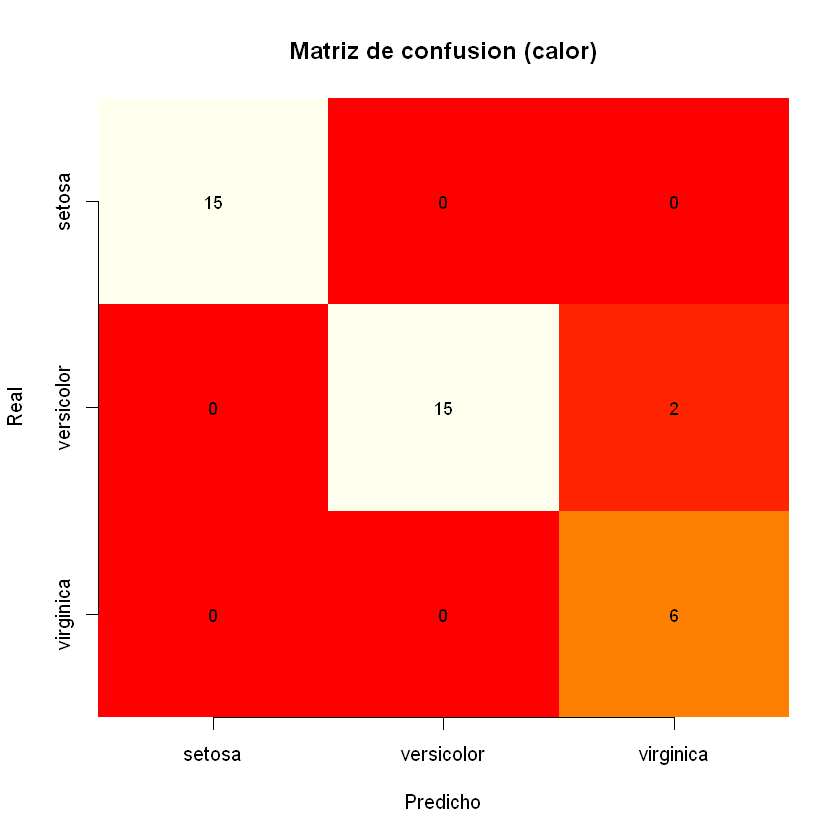

In [12]:
# Convierte matriz a numerico para dibujar calor.
cm_mat <- as.matrix(cm_best)

# Heatmap base.
image(
  1:ncol(cm_mat),
  1:nrow(cm_mat),
  t(cm_mat[nrow(cm_mat):1, ]),
  col = heat.colors(30),
  axes = FALSE,
  xlab = 'Predicho',
  ylab = 'Real',
  main = 'Matriz de confusion (calor)'
)

# Etiquetas de ejes.
axis(1, at = 1:ncol(cm_mat), labels = colnames(cm_mat))
axis(2, at = 1:nrow(cm_mat), labels = rev(rownames(cm_mat)))

# Escribe conteos dentro del mapa.
for (i in 1:nrow(cm_mat)) {
  for (j in 1:ncol(cm_mat)) {
    text(j, nrow(cm_mat) - i + 1, labels = cm_mat[i, j], cex = 0.9)
  }
}


## Variaci?n ?til: confianza local con `prob = TRUE`

`class::knn` permite recuperar la proporci?n de votos de la clase ganadora.
Esto sirve como se?al de confianza local (no es probabilidad calibrada global).


In [13]:
# Predice con atributo de probabilidad del voto ganador.
pred_prob <- knn(
  train = X_train_sc,
  test = X_test_sc,
  cl = y_train,
  k = best_k,
  prob = TRUE
)

# Extrae proporci?n de voto de la clase predicha.
conf_local <- attr(pred_prob, 'prob')

# Muestra primeras observaciones.
head(data.frame(pred = pred_prob, conf_local = round(conf_local, 4)))


,pred,conf_local
,<fct>,<dbl>
1,setosa,1
2,setosa,1
3,setosa,1
4,setosa,1
5,setosa,1
6,setosa,1


## Extra de probabilidad y estad?stica

En lugar de un solo split, repetimos muchos splits para estimar la distribuci?n de accuracy.
Esto ayuda a entender variabilidad del modelo.


Media accuracy: 0.948 


SD accuracy: 0.0305 


IC empirico 95%: 0.8941 1 


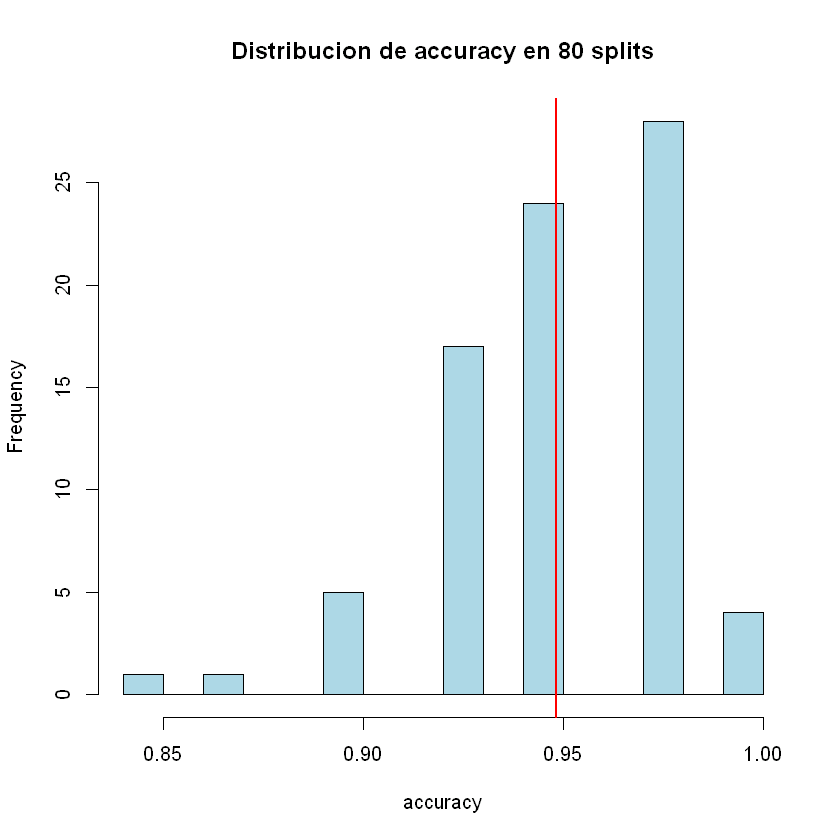

In [14]:
# Repite experimento en varios splits para medir dispersion.
set.seed(777)
reps <- 80
acc_rep <- numeric(reps)

for (r in 1:reps) {
  # Split aleatorio en cada repeticion.
  idx_r <- sample(seq_len(nrow(X)), size = floor(0.75 * nrow(X)))
  Xtr <- X[idx_r, ]
  Xte <- X[-idx_r, ]
  ytr <- y[idx_r]
  yte <- y[-idx_r]

  # Escalado con train del split actual.
  mu_r <- colMeans(Xtr)
  sd_r <- apply(Xtr, 2, sd)
  Xtr_sc <- scale_with(Xtr, mu_r, sd_r)
  Xte_sc <- scale_with(Xte, mu_r, sd_r)

  # Evalua con best_k encontrado antes.
  pred_r <- knn(train = Xtr_sc, test = Xte_sc, cl = ytr, k = best_k)
  acc_rep[r] <- mean(pred_r == yte)
}

# Resumen estadistico de accuracy.
cat('Media accuracy:', round(mean(acc_rep), 4), '
')
cat('SD accuracy:', round(sd(acc_rep), 4), '
')
cat('IC empirico 95%:', round(quantile(acc_rep, c(0.025, 0.975)), 4), '
')

# Distribucion de accuracies.
hist(acc_rep, breaks = 15, col = 'lightblue',
     main = 'Distribucion de accuracy en 80 splits', xlab = 'accuracy')
abline(v = mean(acc_rep), col = 'red', lwd = 2)


## Analog?as r?pidas R y Python

- Flujo correcto en ambos: split -> escalado con train -> entrenamiento -> evaluaci?n.
- `class::knn` (R) y `KNeighborsClassifier` (Python) responden a la misma idea estad?stica.


In [15]:
# Checklist minimo para pipeline correcto.
check_pipeline <- c(
  'split_train_test',
  'fit_scaler_on_train_only',
  'predict_on_test',
  'report_accuracy_and_confusion'
)

check_pipeline


[1] "split_train_test"              "fit_scaler_on_train_only"     
[3] "predict_on_test"               "report_accuracy_and_confusion"

## Errores comunes de esta sesi?n

1. Escalar antes del split (data leakage).
2. Elegir `k` solo por una corrida.
3. Usar solo accuracy sin revisar confusiones por clase.
4. Interpretar `prob` de knn como probabilidad perfectamente calibrada.


In [16]:
# Ilustracion de leakage: escalado incorrecto con todo X.
mu_all <- colMeans(X)
sd_all <- apply(X, 2, sd)

Xtr_leak <- scale_with(X_train, mu_all, sd_all)
Xte_leak <- scale_with(X_test, mu_all, sd_all)

pred_leak <- knn(train = Xtr_leak, test = Xte_leak, cl = y_train, k = best_k)
acc_leak <- mean(pred_leak == y_test)

cat('Accuracy sin fuga:', round(acc_best, 4), '
')
cat('Accuracy con fuga (referencial):', round(acc_leak, 4), '
')


Accuracy sin fuga: 0.9474 


Accuracy con fuga (referencial): 0.9474 


## Ejercicios para pensar (no copiar c?digo)

1. Explica por qu? `k = 1` puede sobreajustar y qu? patr?n esperar?as en train vs test.
2. Dise?a un experimento para comparar estabilidad de `k = 3`, `k = 11` y `k = 25`.
3. Elige una clase y analiza sus errores en matriz de confusi?n: ?qu? variable adicional medir?as para reducirlos?
4. ?Cu?ndo podr?a ser enga?oso reportar solo accuracy en un problema multiclase?
5. Prop?n una regla de negocio para decidir entre un modelo m?s interpretable y uno con mejor accuracy.


In [17]:
# Espacio para resolver ejercicios en R.
# Escribe aqui tus respuestas, pruebas y conclusiones.
